In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install flask pyngrok tensorflow pillow

In [ ]:
from flask import Flask, request, jsonify
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image
import numpy as np
from pyngrok import ngrok
from tensorflow.keras.layers import Layer
import tensorflow as tf
from werkzeug.utils import secure_filename

# Define allowed image types
ALLOWED_EXTENSIONS = {'png', 'jpg', 'jpeg'}

def allowed_file(filename):
    return '.' in filename and filename.rsplit('.', 1)[1].lower() in ALLOWED_EXTENSIONS

# Define custom Cast layer for compatibility
class Cast(Layer):
    def call(self, inputs):
        return tf.cast(inputs, tf.float16)

# Load the trained model
model_path = "/content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5"
model = load_model(model_path, custom_objects={"Cast": Cast})

# Class labels for predictions
class_labels = [
    "Adenocarcinoma Cancer Cell",
    "Large Cell Carcinoma Cancer Cell",
    "Normal Cell",
    "Squamous Cell Carcinoma Cancer Cell"
]

# Setup Flask app
ngrok.set_auth_token("2rInonMJZkVbZFBCLMHqOh4GK5n_3RuT7AHDPG2GdESffcGk5")
app = Flask(__name__)

html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>Lung Cancer Detection Chatbot</title>
    <link href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.0.0/css/all.min.css" rel="stylesheet">
    <style>
        @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;500;700&display=swap');
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
            font-family: 'Poppins', sans-serif;
        }
        body {
            background: linear-gradient(45deg, #6366f1, #8b5cf6, #ec4899);
            height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
            position: relative;
            overflow: hidden;
        }
        .chat-container {
            width: 400px;
            height: 600px;
            background: rgba(255, 255, 255, 0.95);
            border-radius: 25px;
            box-shadow: 0 15px 45px rgba(0,0,0,0.3);
            display: flex;
            flex-direction: column;
            backdrop-filter: blur(10px);
            border: 1px solid rgba(255,255,255,0.2);
        }
        .chat-header {
            background: linear-gradient(135deg, #6366f1, #8b5cf6);
            padding: 25px;
            border-radius: 25px 25px 0 0;
            color: white;
            text-align: center;
            font-size: 1.3em;
            display: flex;
            justify-content: space-between;
            align-items: center;
            box-shadow: 0 5px 15px rgba(0,0,0,0.1);
        }
        .clear-btn {
            background: rgba(255,255,255,0.2);
            border: none;
            padding: 8px 15px;
            border-radius: 20px;
            color: white;
            cursor: pointer;
            transition: 0.3s;
        }
        .clear-btn:hover {
            background: rgba(255,255,255,0.3);
        }
        .chat-messages {
            flex: 1;
            padding: 20px;
            overflow-y: auto;
            display: flex;
            flex-direction: column;
            gap: 15px;
            background: linear-gradient(to bottom right, rgba(255,255,255,0.9), rgba(245,245,245,0.9));
        }
        .message {
            max-width: 80%;
            padding: 15px 20px;
            border-radius: 20px;
            animation: slideIn 0.3s cubic-bezier(0.25, 0.46, 0.45, 0.94);
            position: relative;
            box-shadow: 0 5px 15px rgba(0,0,0,0.05);
        }
        .user-message {
            background: #6366f1;
            color: white;
            align-self: flex-end;
            border-radius: 20px 20px 0 20px;
        }
        .bot-message {
            background: white;
            color: #333;
            align-self: flex-start;
            border-radius: 20px 20px 20px 0;
            border: 1px solid #eee;
        }
        .upload-container {
            padding: 20px;
            border-top: 1px solid rgba(0,0,0,0.05);
            position: relative;
            background: rgba(255,255,255,0.9);
            border-radius: 0 0 25px 25px;
        }
        .upload-label {
            background: white;
            color: #6366f1;
            padding: 12px 25px;
            border-radius: 30px;
            cursor: pointer;
            display: flex;
            align-items: center;
            justify-content: center;
            gap: 10px;
            transition: 0.3s;
            border: 2px solid #6366f1;
            box-shadow: 0 5px 15px rgba(99,102,241,0.2);
        }
        .upload-label:hover {
            background: #6366f1;
            color: white;
            transform: translateY(-2px);
        }
        #file-input {
            display: none;
        }
        .preview-image {
            max-width: 100%;
            border-radius: 15px;
            margin-top: 10px;
            border: 3px solid white;
            box-shadow: 0 5px 15px rgba(0,0,0,0.1);
        }
        .confidence-bar {
            height: 8px;
            background: #eee;
            border-radius: 4px;
            margin: 10px 0;
            overflow: hidden;
        }
        .confidence-fill {
            height: 100%;
            background: linear-gradient(90deg, #10b981, #3b82f6);
            transition: width 0.5s ease;
        }
        @keyframes slideIn {
            from { opacity: 0; transform: translateY(20px); }
            to { opacity: 1; transform: translateY(0); }
        }
        .floating-bg {
            position: absolute;
            width: 200px;
            height: 200px;
            background: rgba(255,255,255,0.1);
            border-radius: 50%;
            filter: blur(60px);
            animation: float 20s infinite;
        }
        @keyframes float {
            0% { transform: translate(0, 0) rotate(0deg); }
            25% { transform: translate(100px, 100px) rotate(90deg); }
            50% { transform: translate(-50px, 150px) rotate(180deg); }
            75% { transform: translate(-100px, -50px) rotate(270deg); }
            100% { transform: translate(0, 0) rotate(360deg); }
        }
    </style>
</head>
<body>
    <div class="floating-bg" style="top:10%; left:10%"></div>
    <div class="floating-bg" style="top:70%; right:10%"></div>

    <div class="chat-container">
        <div class="chat-header">
            <div>🩺 Cancer Detection AI</div>
            <button class="clear-btn" onclick="clearChat()">
                <i class="fas fa-eraser"></i> Clear
            </button>
        </div>

        <div class="chat-messages" id="chat-messages">
            <div class="message bot-message">
                👋 Hello! I'm here to help analyze lung cell images.
                Upload a microscopic image to get started.
            </div>
        </div>

        <div class="upload-container">
            <label class="upload-label">
                <input type="file" id="file-input" accept="image/*" required>
                <i class="fas fa-cloud-upload-alt"></i>
                Choose Image
            </label>
        </div>
    </div>

    <script>
        const fileInput = document.getElementById('file-input');
        const chatMessages = document.getElementById('chat-messages');

        function clearChat() {
            chatMessages.innerHTML = `
                <div class="message bot-message">
                    👋 Hello! I'm here to help analyze lung cell images.
                    Upload a microscopic image to get started.
                </div>
            `;
        }

        fileInput.addEventListener('change', async (e) => {
            const file = e.target.files[0];
            if (!file) return;

            // Display user's uploaded image
            const reader = new FileReader();
            reader.onload = (e) => {
                const img = document.createElement('img');
                img.src = e.target.result;
                img.className = 'preview-image';

                const userDiv = document.createElement('div');
                userDiv.className = 'message user-message';
                userDiv.innerHTML = '<strong>📤 Uploaded Image:</strong>';
                userDiv.appendChild(img);

                chatMessages.appendChild(userDiv);
                chatMessages.scrollTop = chatMessages.scrollHeight;
            }
            reader.readAsDataURL(file);

            // Send to server
            const formData = new FormData();
            formData.append('file', file);

            try {
                const response = await fetch('/predict', {
                    method: 'POST',
                    body: formData
                });

                const data = await response.json();

                // Display bot response
                const botDiv = document.createElement('div');
                botDiv.className = 'message bot-message';
                botDiv.innerHTML = `
                    <strong>🔍 Analysis Result:</strong>
                    <div style="margin-top: 10px; color: #6366f1">
                         ${data.prediction}
                    </div>
                    <div class="confidence-bar">
                        <div class="confidence-fill" style="width: ${data.confidence}%"></div>
                    </div>
                    <div style="color: #666; font-size: 0.9em">
                        Confidence: ${data.confidence}%
                    </div>
                `;

                chatMessages.appendChild(botDiv);
                chatMessages.scrollTop = chatMessages.scrollHeight;
            } catch (error) {
                alert('Error processing image: ' + error.message);
            }
        });
    </script>
</body>
</html>
"""


@app.route("/")
def home():
    return html_template  # Keep your existing HTML template here

@app.route("/predict", methods=["POST"])
def predict():
    if "file" not in request.files:
        return jsonify({"error": "No file part in the request."}), 400

    file = request.files["file"]

    if file.filename == "":
        return jsonify({"error": "No file selected for uploading."}), 400

    if not allowed_file(file.filename):
        return jsonify({"error": "Invalid file format. Only JPG, JPEG, and PNG are allowed."}), 400

    try:
        filename = secure_filename(file.filename)
        img = Image.open(file).convert("RGB").resize((224, 224))  # Ensure it’s a real image
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class = class_labels[np.argmax(predictions)]
        confidence = np.max(predictions) * 100

        return jsonify({
            "prediction": predicted_class,
            "confidence": f"{confidence:.2f}"
        })

    except Exception as e:
        return jsonify({"error": "Invalid image content. Please upload a valid medical image (JPG/PNG)."}), 400

# Start the app
public_url = ngrok.connect(5000)
print(f"Public URL: {public_url}")
app.run(port=5000)

Public URL: NgrokTunnel: "https://f8be-34-126-181-15.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


Found 315 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 236s 25s/step


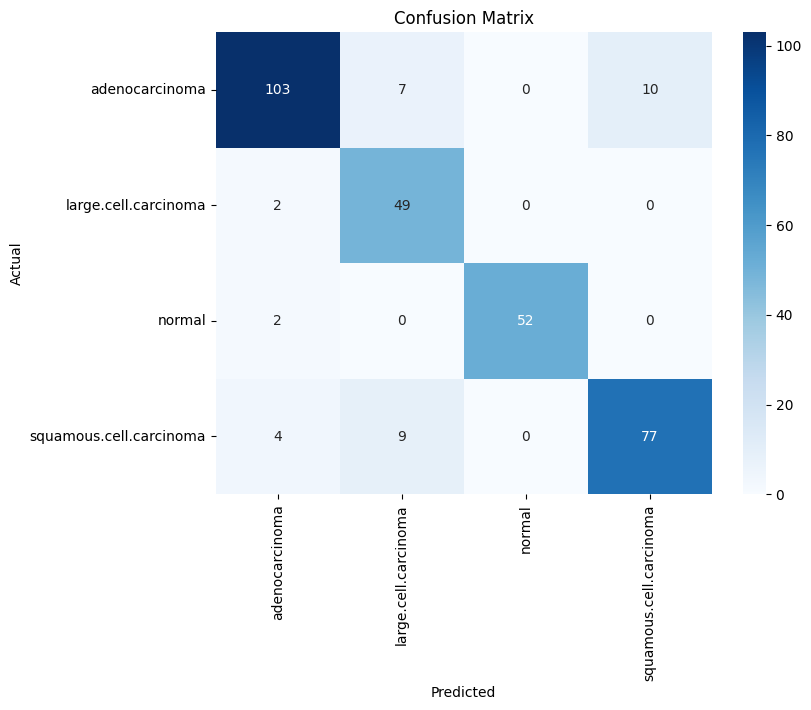

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma       0.93      0.86      0.89       120
   large.cell.carcinoma       0.75      0.96      0.84        51
                 normal       1.00      0.96      0.98        54
squamous.cell.carcinoma       0.89      0.86      0.87        90

               accuracy                           0.89       315
              macro avg       0.89      0.91      0.90       315
           weighted avg       0.90      0.89      0.89       315



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
model_path = "/content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5"
model = load_model(model_path, custom_objects={"Cast": Cast})
test_dir = '/content/drive/MyDrive/LungCancer/Data/test'
img_height, img_width = 224, 224
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # important for consistent labels
)

# Get class labels
class_labels = list(test_generator.class_indices.keys())
y_pred_probs = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))



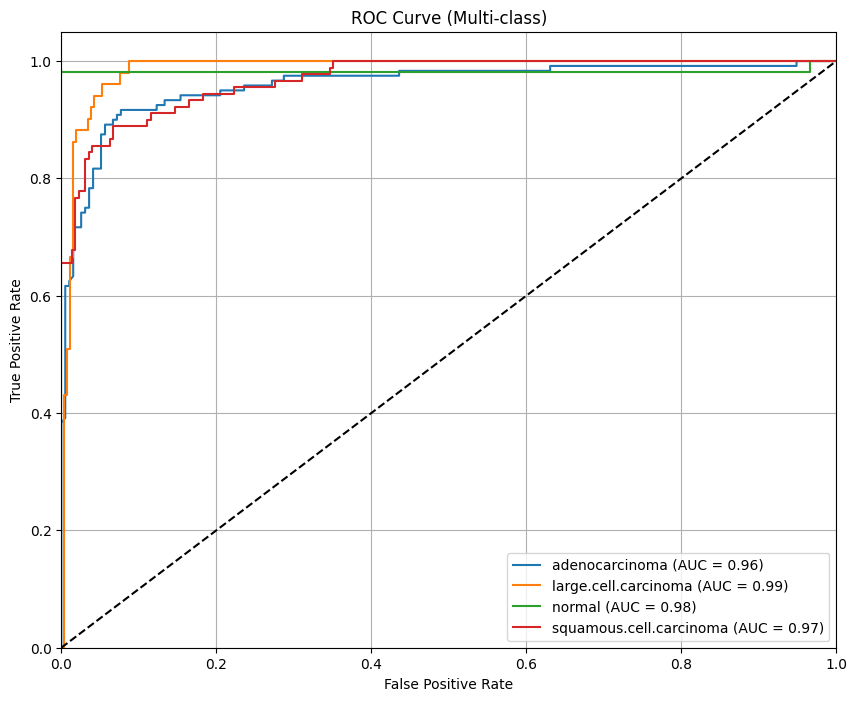

In [ ]:
# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
